## 📌 Project Overview

This project focuses on predicting whether a bank client will subscribe to a term deposit using machine learning models.

The task is a **binary classification problem**, where the target is "Yes" or "No".

The dataset is based on direct marketing campaigns (phone calls) from a banking institution. The goal is to better understand customer behavior and support decision-making in marketing.

The goal is to build an interpretable and reliable model that can be used in real business scenarios.

---

## 📊 Dataset

The dataset includes:
- Customer information (age, job, education, etc.)
- Campaign data (number of contacts, previous interactions)
- Macroeconomic indicators (interest rate, employment, consumer indices)

Target variable:
- **y** — whether the client subscribed to a term deposit

---

## ⚠️ Important Note

The feature *duration* is not used in the final model because it causes **data leakage**.
It is only known after the call and is directly related to the target.

---

## 🔍 Project Steps

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Model training and evaluation
- Model interpretation (feature importance, SHAP)
- Error analysis

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import randint, uniform
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import shap



pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

EDA

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [4]:
df.shape

(41188, 21)

Conclusion: The dataset has 41,188 rows and 21 columns.


In [5]:
# dataset structure
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Conclusion:** The dataset contains both numerical and categorical variables.
Numerical features are stored as *int64* (5) and *float64* (5), while categorical features are stored as *object* (11).


In [6]:
# check missing values - NaN
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Conclusion:** There are no missing values (NaN) in the dataset.


In [7]:
# check 'unknown'
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

**Conclusion:** Earlier it was noted that there are no missing values (NaN) in the dataset, but there are *unknown* values in the following columns:
*job, marital, education, default, housing, loan*.
These represent unknown or hidden information.


In [8]:
# divide dataset into num and cat cols
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
print(num_cols), print(cat_cols)
len(num_cols), len(cat_cols)


Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


(10, 11)

**Conclusion:** The dataset contains 10 numerical variables and 11 categorical variables.


In [9]:
# target analysis
df['y'].value_counts().sort_values(ascending=False)

y
no     36548
yes     4640
Name: count, dtype: int64

In [10]:
df['y'].value_counts(normalize=True)

y
no    0.89
yes   0.11
Name: proportion, dtype: float64

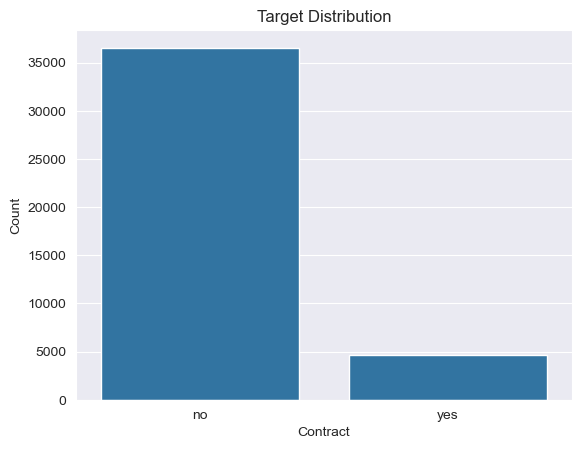

In [115]:
sns.countplot(x='y', data=df)
plt.title('Target Distribution')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.savefig('target.png')
plt.show()

**Conclusion:** There is a strong class imbalance.
"No" makes up 89%, while "Yes" makes up 11%.
This should be taken into account when building the model.


In [12]:
# numerical features analysis
# statistics
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


**Conclusion:** Numerical variables have different scales.
In the *pdays* column (number of days since the last contact in a previous campaign), the value *999* means that the client was not contacted before.







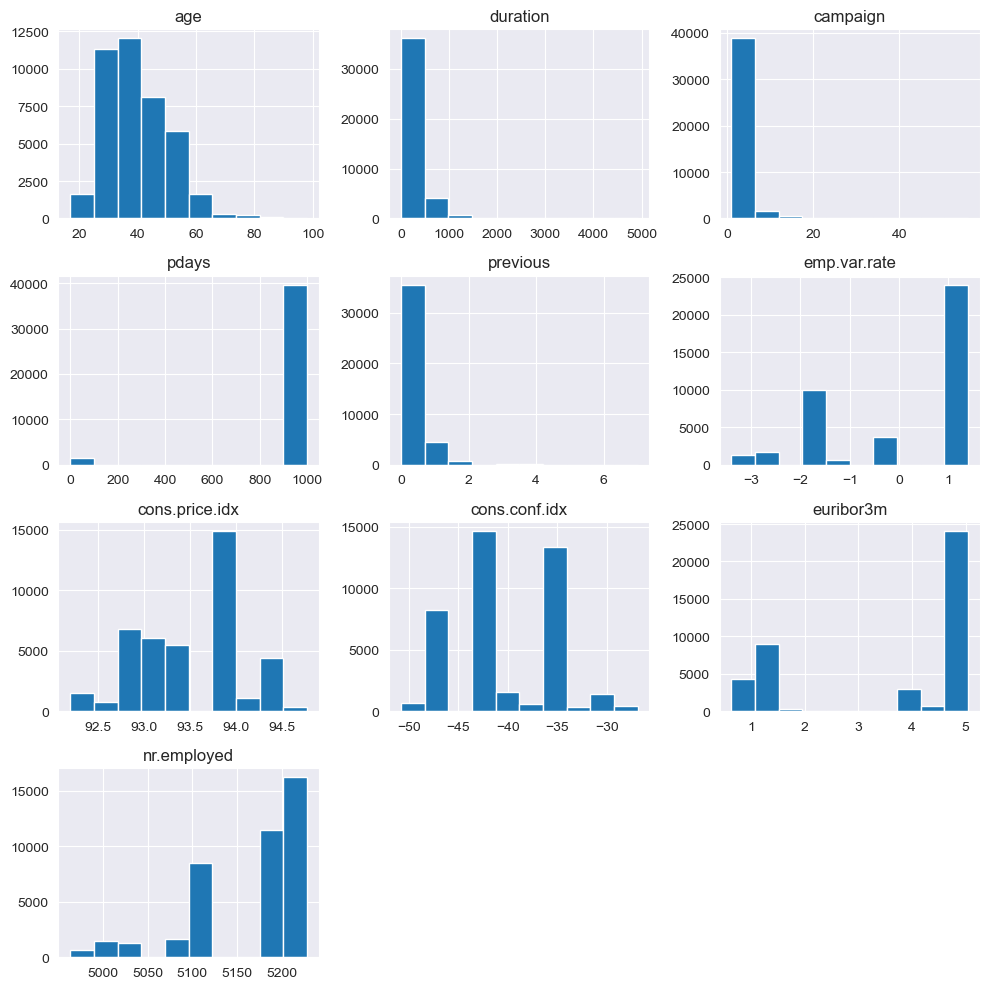

In [13]:
# visualization
df.hist(figsize=(10,10))
plt.tight_layout()
plt.show()

In [14]:
# check connections between numeric features
corr_matrix = df.corr(numeric_only=True)

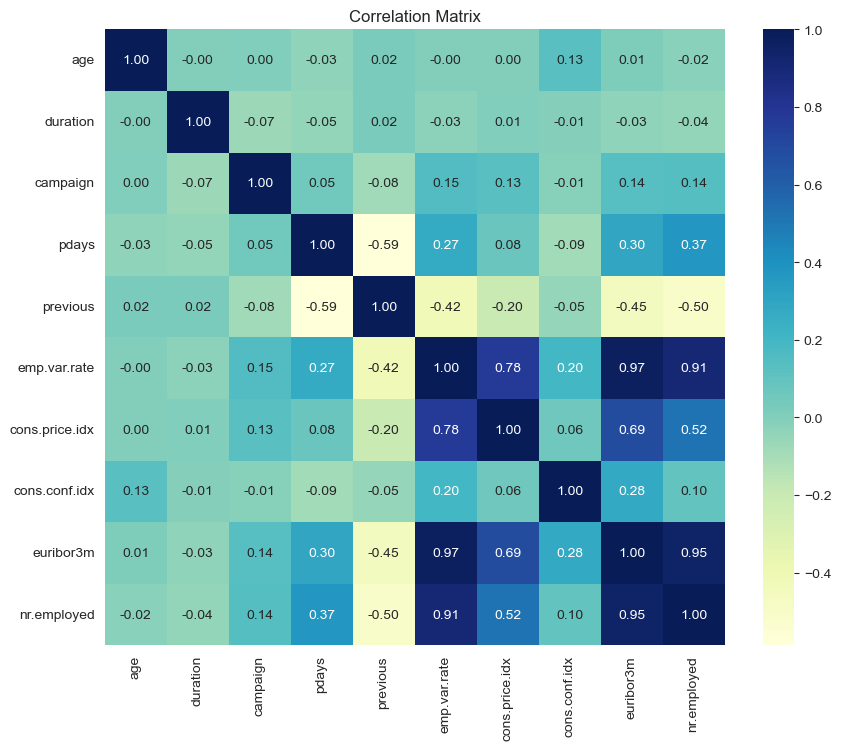

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

**Conclusion:** The correlation matrix shows that some numerical features are strongly related.
We focus on correlation values between 0.7 and 1.0 (purple range).
The most significant correlations are:
*euribor3m / nr.employed = 0.95*;
*euribor3m / emp.var.rate = 0.97*;
*nr.employed / emp.var.rate = 0.91*.


In [16]:
# categorical features analysis
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

Below, I will look at some of them in more detail.

In [17]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [18]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [19]:
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [20]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [21]:
df['housing'].value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [22]:
df['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

Below, I will analyze categorical variables in relation to the target.

<Figure size 1000x500 with 0 Axes>

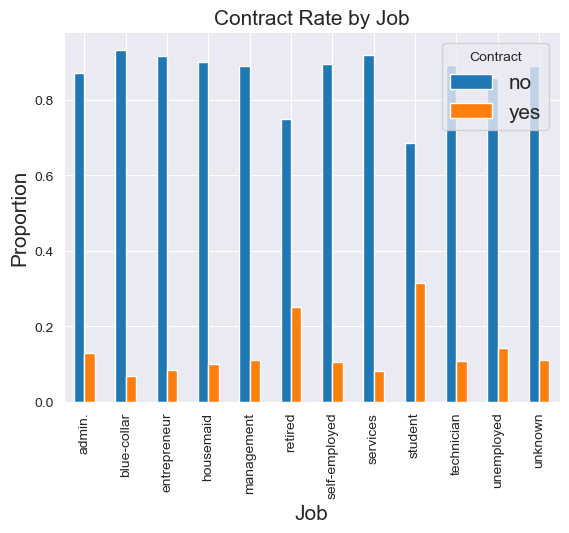

In [23]:
# 'job' column
plt.figure(figsize=(10,5))

df.groupby('job')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Job', fontsize=15)
plt.xlabel('Job', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()


<Figure size 1000x500 with 0 Axes>

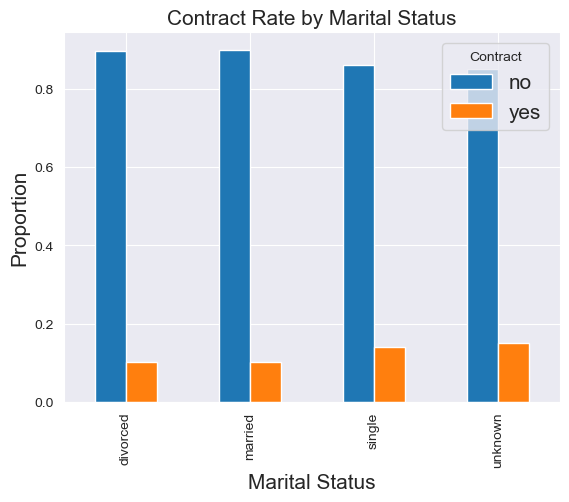

In [24]:
# 'marital' column
plt.figure(figsize=(10,5))

df.groupby('marital')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Marital Status', fontsize=15)
plt.xlabel('Marital Status', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

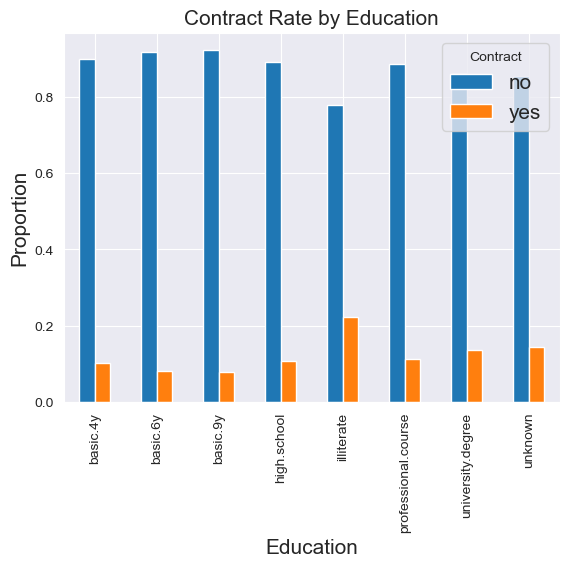

In [25]:
# 'education' column
plt.figure(figsize=(10,5))

df.groupby('education')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Education', fontsize=15)
plt.xlabel('Education', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

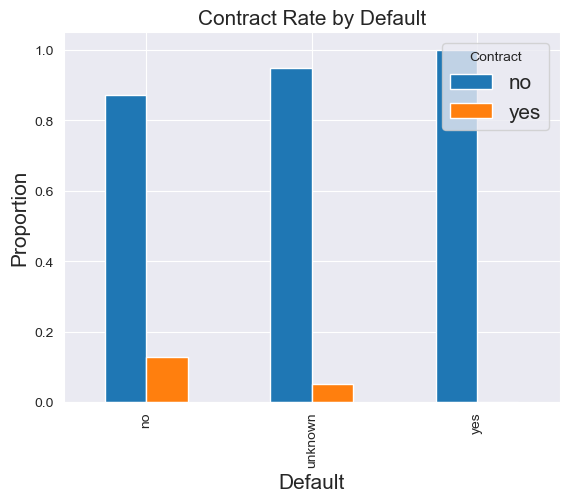

In [26]:
# 'default' column
plt.figure(figsize=(10,5))

df.groupby('default')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Default', fontsize=15)
plt.xlabel('Default', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

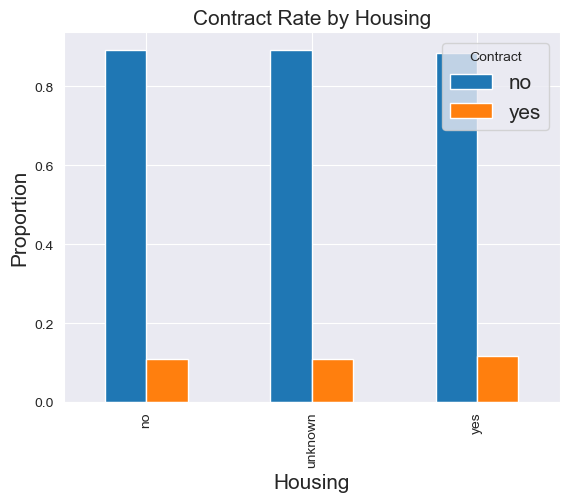

In [27]:
# 'housing' column
plt.figure(figsize=(10,5))

df.groupby('housing')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Housing', fontsize=15)
plt.xlabel('Housing', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

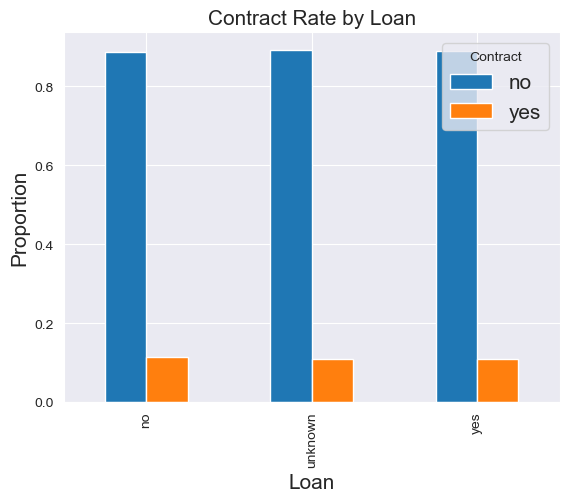

In [28]:
# 'loan' column
plt.figure(figsize=(10,5))

df.groupby('loan')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Loan', fontsize=15)
plt.xlabel('Loan', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

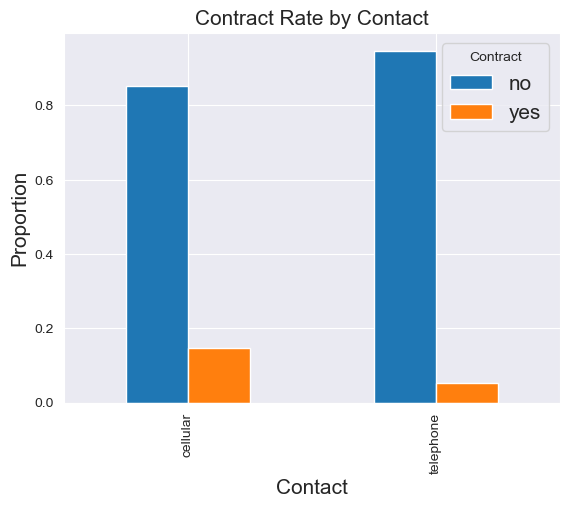

In [29]:
# 'contact' column
plt.figure(figsize=(10,5))

df.groupby('contact')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Contact', fontsize=15)
plt.xlabel('Contact', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

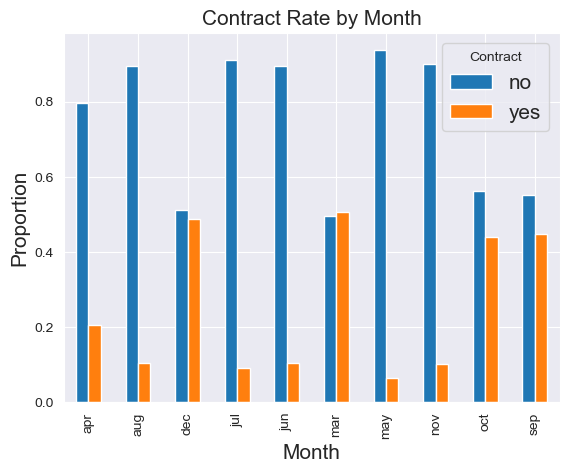

In [30]:
# 'month' column
plt.figure(figsize=(10,5))

df.groupby('month')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Month', fontsize=15)
plt.xlabel('Month', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

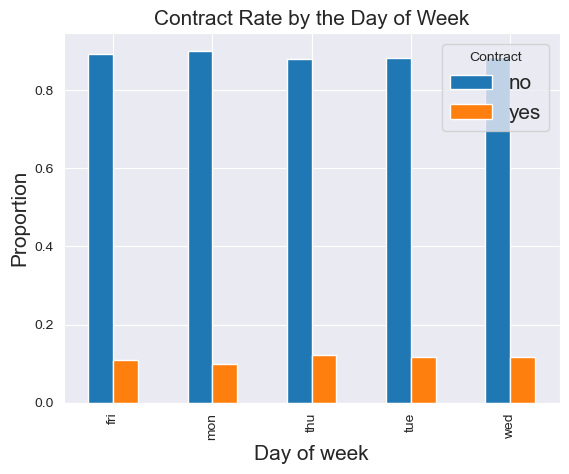

In [31]:
# 'day_of_week' column
plt.figure(figsize=(10,5))

df.groupby('day_of_week')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by the Day of Week', fontsize=15)
plt.xlabel('Day of week', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

<Figure size 1000x500 with 0 Axes>

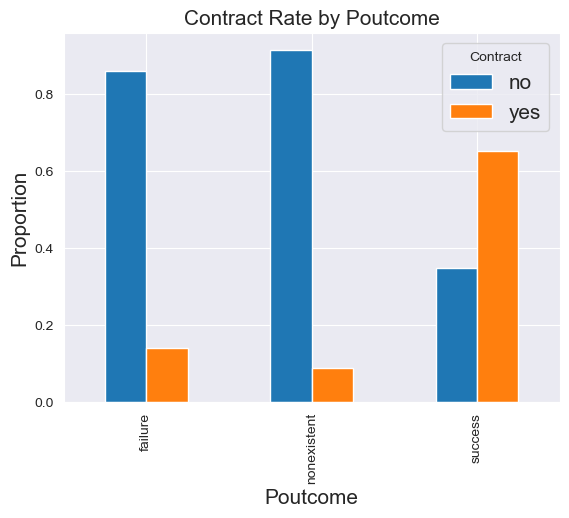

In [32]:
# 'poutcome' column
plt.figure(figsize=(10,5))

df.groupby('poutcome')['y'].value_counts(normalize = True).unstack().plot(kind='bar')

plt.title('Contract Rate by Poutcome', fontsize=15)
plt.xlabel('Poutcome', fontsize=15)
plt.ylabel('Proportion', fontsize=15)
plt.legend(title='Contract', fontsize=15)
plt.show()

Below, I will analyze numerical variables in relation to the target.

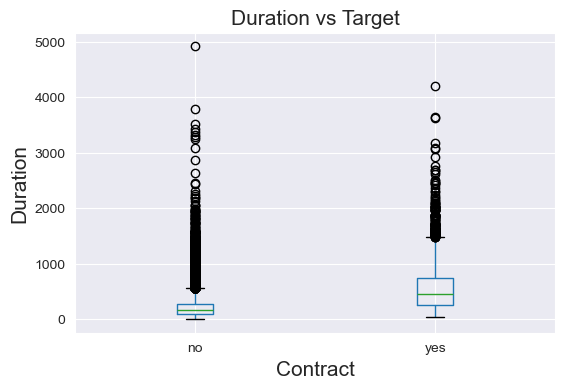

In [33]:
# 'duration' vs target
df.boxplot(column = 'duration', by = 'y', figsize = (6,4))
plt.title('Duration vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('Duration', fontsize=15)
plt.show()

**Conclusion:** This feature has a strong impact on the target, but it is a data leakage feature, so it should only be used for model comparison.


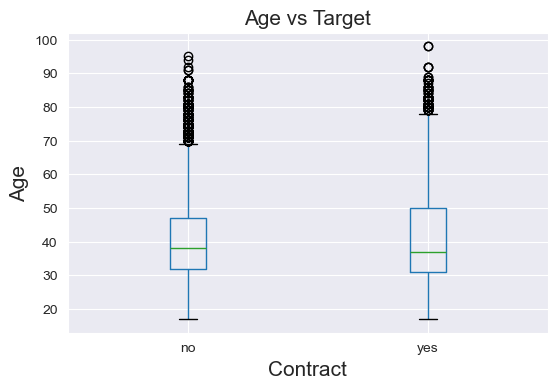

In [34]:
# 'age' vs target
df.boxplot(column = 'age', by = 'y', figsize = (6,4))
plt.title('Age vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('Age', fontsize=15)
plt.show()

**Conclusion:** The average age is almost the same across the groups, which suggests it is not very important for the target.


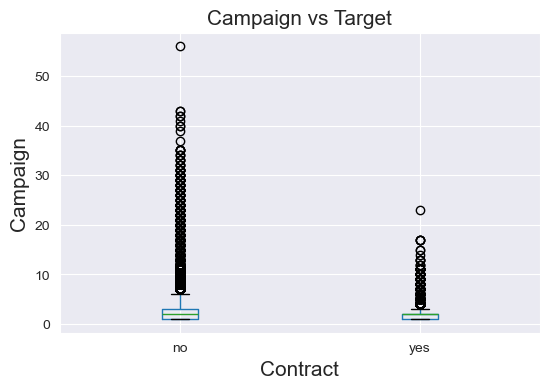

In [35]:
# 'campaign' vs target
df.boxplot(column = 'campaign', by = 'y', figsize = (6,4))
plt.title('Campaign vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('Campaign', fontsize=15)
plt.show()

**Conclusion:** A higher number of contacts does not increase the chance of making a contract; it may even reduce the chances. Therefore, this variable has an impact on the target.


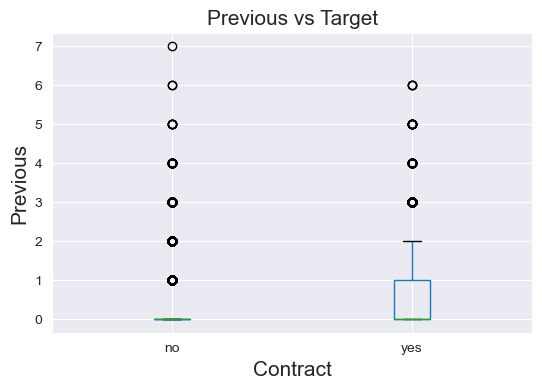

In [36]:
# 'previous' vs target
df.boxplot(column = 'previous', by = 'y', figsize = (6,4))
plt.title('Previous vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('Previous', fontsize=15)
plt.show()

**Conclusion:** Clients with a higher number of previous contacts were more likely to say "Yes," meaning past interaction history generally had a positive effect on the outcome.


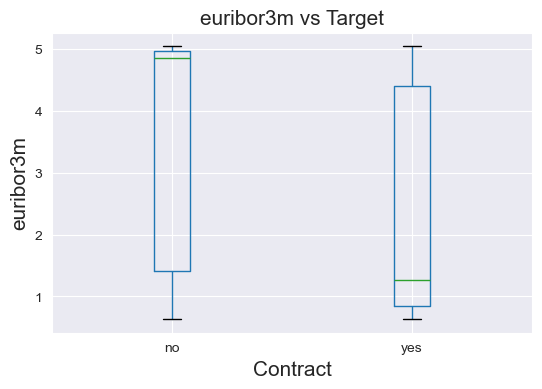

In [37]:
# 'euribor3m' vs target
df.boxplot(column = 'euribor3m', by = 'y', figsize = (6,4))
plt.title('euribor3m vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('euribor3m', fontsize=15)
plt.show()

Conclusion: This feature has an impact on the target.

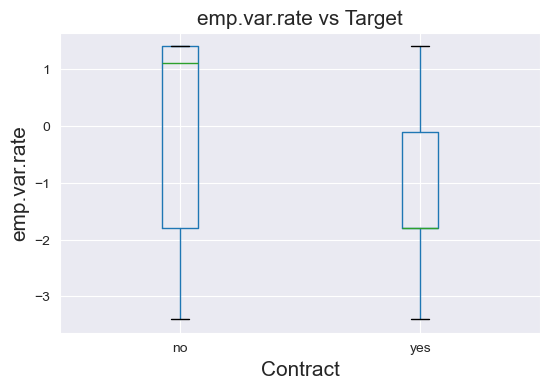

In [38]:
# 'emp.var.rate' vs target
df.boxplot(column = 'emp.var.rate', by = 'y', figsize = (6,4))
plt.title('emp.var.rate vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('emp.var.rate', fontsize=15)
plt.show()

**Conclusion:** There is a strong impact of this feature on the target.


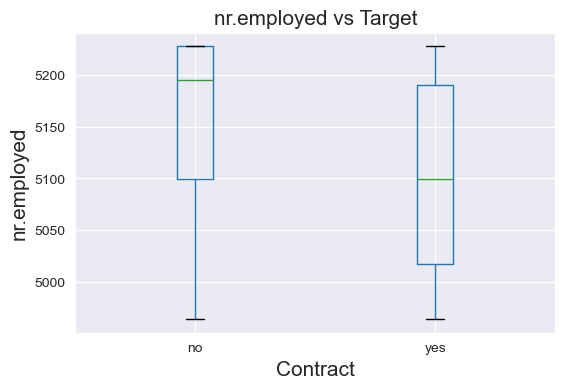

In [39]:
# 'nr.employed' vs target
df.boxplot(column = 'nr.employed', by = 'y', figsize = (6,4))
plt.title('nr.employed vs Target', fontsize=15)
plt.suptitle('')
plt.xlabel('Contract', fontsize=15)
plt.ylabel('nr.employed', fontsize=15)
plt.show()

**Conclusion:** There is a strong impact of this feature on the target.


METRIC SELECTION AND JUSTIFICATION:

In this project, I solve a binary classification problem, where the goal is to predict the target as "Yes" or "No".

An important aspect of this dataset is class imbalance, which strongly affects the choice of metrics. Accuracy is not suitable here, because the model may often predict "No" (since it is the majority class) and still get a high score.

Instead, ROC-AUC is used to evaluate how well the model separates positive and negative classes. A score of 1 means perfect performance, while 0.5 means the model is no better than random guessing, which is not useful for business.

I also use the F1-score, which is the harmonic mean of precision and recall. It helps to balance how accurately the model predicts "Yes" (precision) and how well it identifies positive cases (recall).

In [40]:
# Data Preprocessing
# copy of original df
df_model = df.copy()

In [41]:
# drop 'duration' to avoid data leakage
df_model = df_model.drop('duration', axis = 1)

In [42]:
# categorical columns
# replace 'unknown' with 'missing'
df_model = df_model.replace('unknown', 'missing')

In [43]:
# additional feature based on 'pdays'
df_model['was_contacted_before'] = (df_model['pdays'] != 999).astype(int)

In [44]:
# replace special value 999 in 'pdays'
df_model['pdays'] = df_model['pdays'].replace(999, -1)

In [45]:
# encode target
df_model['y'] = df_model['y'].map({'yes':1, 'no':0})

In [46]:
# data split into features and target
X = df_model.drop('y', axis = 1)
y = df_model['y']

In [47]:
# train-test split using stratify for class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [48]:
# one-hot encoding for categorical variables
X_train = pd.get_dummies(X_train, drop_first = True)
X_test = pd.get_dummies(X_test, drop_first = True)

In [96]:
# align columns in train and trest sets
X_train, X_test = X_train.align(X_test, join = 'left', axis = 1, fill_value = 0)

In [97]:
# save feature names for shap visualization
original_columns = X_train.columns

In [98]:
# scaling for Log. Reg. and kNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
# check the shape
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('X_train_scaled:', X_train_scaled.shape)
print('X_test_scaled:', X_test_scaled.shape)

X_train: (32950, 53)
X_test: (8238, 53)
y_train: (32950,)
y_test: (8238,)
X_train_scaled: (32950, 53)
X_test_scaled: (8238, 53)


In [52]:
# Logistic Regression baseline
log_reg = LogisticRegression(solver = 'liblinear', random_state = 42)
log_reg.fit(X_train_scaled, y_train)

log_reg_train_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
log_reg_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

log_reg_train_pred = log_reg.predict(X_train_scaled)
log_reg_test_pred = log_reg.predict(X_test_scaled)

# ROC-AUC - probabilities, F1-score - predict
print('Logistic Regression')
print('Train ROC-AUC:', roc_auc_score(y_train, log_reg_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, log_reg_test_proba))
print('Test F1:', f1_score(y_test, log_reg_test_pred))

Logistic Regression
Train ROC-AUC: 0.793211891490703
Test ROC-AUC: 0.8008802744233219
Test F1: 0.3368592351505289


Conclusion: The baseline Logistic Regression model showed good ROC-AUC performance (0.80), meaning it separates classes well. However, the F1-score is low due to class imbalance, so the model still needs improvement.





In [53]:
# Tuned logistic regression experiment
log_reg_tuned = LogisticRegression(
    solver = 'liblinear',
    random_state = 42,
    max_iter = 1000,
    class_weight = 'balanced',
    C = 1.0,
    penalty = 'l2',
)
log_reg_tuned.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [54]:
log_reg_tuned_train_proba = log_reg_tuned.predict_proba(X_train_scaled)[:, 1]
log_reg_tuned_test_proba = log_reg_tuned.predict_proba(X_test_scaled)[:, 1]

In [55]:
# F1 score improvement
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    preds = (log_reg_tuned_test_proba >= threshold).astype(int)
    f1 = f1_score(y_test, preds)
    print(f'Threshold: {threshold} | F1: {f1:.4f}')



Threshold: 0.2 | F1: 0.2176
Threshold: 0.3 | F1: 0.2774
Threshold: 0.4 | F1: 0.3969
Threshold: 0.5 | F1: 0.4689
Threshold: 0.6 | F1: 0.5011
Threshold: 0.7 | F1: 0.4992
Threshold: 0.8 | F1: 0.4591
Threshold: 0.9 | F1: 0.3270


In [56]:
best_threshold = 0.6

log_reg_tuned_train_pred = (log_reg_tuned_train_proba >= best_threshold).astype(int)
log_reg_tuned_test_pred = (log_reg_tuned_test_proba >= best_threshold).astype(int)

In [57]:
print('Tuned Logistic Regression')
print('Train ROC-AUC:', roc_auc_score(y_train, log_reg_tuned_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, log_reg_tuned_test_proba))
print('Train F1:', f1_score(y_train, log_reg_tuned_train_pred))
print('Test F1:', f1_score(y_test, log_reg_tuned_test_pred))
print('Best threshold:', best_threshold)

Tuned Logistic Regression
Train ROC-AUC: 0.795111967354423
Test ROC-AUC: 0.8009467575121467
Train F1: 0.4764369675401704
Test F1: 0.5010817827780182
Best threshold: 0.6


**Conclusion:** Threshold tuning improved the model’s F1-score from 0.33 to 0.50.


In [58]:
# kNN Baseline
knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train_scaled, y_train)

knn_train_proba = knn.predict_proba(X_train_scaled)[:, 1]
knn_test_proba = knn.predict_proba(X_test_scaled)[:, 1]

knn_train_pred = knn.predict(X_train_scaled)
knn_test_pred = knn.predict(X_test_scaled)

print('kNN baseline')
print('Train ROC-AUC:', roc_auc_score(y_train, knn_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, knn_test_proba))
print('Train F1:', f1_score(y_train, knn_train_pred))
print('Test F1:', f1_score(y_test, knn_test_pred))
print('n_neighbors:', 5)


kNN baseline
Train ROC-AUC: 0.9228032285865584
Test ROC-AUC: 0.7346261173876127
Train F1: 0.4851924100017734
Test F1: 0.37165582067968184
n_neighbors: 5


**Conclusion:** The model is overfitting with this number of neighbors.
A downside of this model is that we need to find the optimal number of neighbors.
Below, I will try to improve the model.


In [59]:
# kNN improvement
neighbors = [40, 45, 50, 60, 70, 80, 90, 100]

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    knn_test_proba = knn.predict_proba(X_test_scaled)[:, 1]
    knn_test_pred = knn.predict(X_test_scaled)

    roc_auc = roc_auc_score(y_test, knn_test_proba)
    f1 = f1_score(y_test, knn_test_pred)

    print(f'n_neighbors: {k} | ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f}')

n_neighbors: 40 | ROC-AUC: 0.7789 | F1: 0.3264
n_neighbors: 45 | ROC-AUC: 0.7777 | F1: 0.3257
n_neighbors: 50 | ROC-AUC: 0.7803 | F1: 0.3211
n_neighbors: 60 | ROC-AUC: 0.7872 | F1: 0.3183
n_neighbors: 70 | ROC-AUC: 0.7887 | F1: 0.3192
n_neighbors: 80 | ROC-AUC: 0.7874 | F1: 0.3170
n_neighbors: 90 | ROC-AUC: 0.7864 | F1: 0.3103
n_neighbors: 100 | ROC-AUC: 0.7852 | F1: 0.3095


**Conclusion:** The best ROC-AUC score was achieved at *n_neighbors = 70*. Further tuning leads to a decrease in model performance.
Compared to Logistic Regression (0.80), kNN performs slightly worse (0.789).


In [60]:
# Baseline Decision tree (X_train, X_test), no scaling needed
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_train_proba = tree.predict_proba(X_train)[:, 1]
tree_test_proba = tree.predict_proba(X_test)[:, 1]

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)

print('Decision Tree baseline')
print('Train ROC-AUC:', roc_auc_score(y_train, tree_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, tree_test_proba))
print('Train F1:', f1_score(y_train, tree_train_pred))
print('Test F1:', f1_score(y_test, tree_test_pred))

Decision Tree baseline
Train ROC-AUC: 0.9998924689630995
Test ROC-AUC: 0.6258552879852823
Train F1: 0.9792439862542955
Test F1: 0.3268041237113402


**Conclusion:** The baseline Decision Tree model shows overfitting: performance is high on the training data but very low on the test data. The model generalizes poorly. Below, I will try to improve it by tuning the depth.


In [61]:
# depth search
depths = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15]

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    tree_test_proba = tree.predict_proba(X_test)[:, 1]
    tree_test_pred = tree.predict(X_test)

    roc_auc = roc_auc_score(y_test, tree_test_proba)
    f1 = f1_score(y_test, tree_test_pred)

    print(f'max_depth: {depth} | ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f}')

max_depth: 2 | ROC-AUC: 0.7537 | F1: 0.2902
max_depth: 3 | ROC-AUC: 0.7604 | F1: 0.3009
max_depth: 4 | ROC-AUC: 0.7699 | F1: 0.3140
max_depth: 5 | ROC-AUC: 0.7902 | F1: 0.3693
max_depth: 6 | ROC-AUC: 0.7954 | F1: 0.3659
max_depth: 7 | ROC-AUC: 0.7967 | F1: 0.4101
max_depth: 8 | ROC-AUC: 0.7908 | F1: 0.3781
max_depth: 10 | ROC-AUC: 0.7659 | F1: 0.4060
max_depth: 12 | ROC-AUC: 0.7175 | F1: 0.4077
max_depth: 15 | ROC-AUC: 0.6482 | F1: 0.3997


**Conclusion:** The optimal depth found is 7, where the model achieves the highest ROC-AUC of 0.79.
However, this result is not better than Logistic Regression and is similar to kNN.


In [62]:
# leaves search
leaves = [20, 30, 40, 50, 60, 70, 80]

for leaf in leaves:
    tree = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=leaf,
        random_state=42
    )
    tree.fit(X_train, y_train)

    tree_test_proba = tree.predict_proba(X_test)[:, 1]
    tree_test_pred = tree.predict(X_test)

    roc_auc = roc_auc_score(y_test, tree_test_proba)
    f1 = f1_score(y_test, tree_test_pred)

    print(f'min_samples_leaf: {leaf} | ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f}')

min_samples_leaf: 20 | ROC-AUC: 0.7911 | F1: 0.3626
min_samples_leaf: 30 | ROC-AUC: 0.7914 | F1: 0.3655
min_samples_leaf: 40 | ROC-AUC: 0.7912 | F1: 0.3549
min_samples_leaf: 50 | ROC-AUC: 0.7915 | F1: 0.3487
min_samples_leaf: 60 | ROC-AUC: 0.7964 | F1: 0.3454
min_samples_leaf: 70 | ROC-AUC: 0.7964 | F1: 0.3454
min_samples_leaf: 80 | ROC-AUC: 0.7957 | F1: 0.3595


**Conclusion:** Further tuning of the Decision Tree model did not improve performance: ROC-AUC stayed the same as with depth tuning, and the F1-score decreased. Therefore, the final Decision Tree model will be used without *min_samples_leaf*.


In [63]:
best_depth = 7

tree_tuned = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

tree_tuned.fit(X_train, y_train)

tree_tuned_train_proba = tree_tuned.predict_proba(X_train)[:, 1]
tree_tuned_test_proba = tree_tuned.predict_proba(X_test)[:, 1]

tree_tuned_train_pred = tree_tuned.predict(X_train)
tree_tuned_test_pred = tree_tuned.predict(X_test)

print('Tuned Decision Tree')
print('Train ROC-AUC:', roc_auc_score(y_train, tree_tuned_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, tree_tuned_test_proba))
print('Train F1:', f1_score(y_train, tree_tuned_train_pred))
print('Test F1:', f1_score(y_test, tree_tuned_test_pred))
print('Best max_depth:', best_depth)

Tuned Decision Tree
Train ROC-AUC: 0.8009739913560175
Test ROC-AUC: 0.7967281033303458
Train F1: 0.4453750910415149
Test F1: 0.4101449275362319
Best max_depth: 7


**Conclusion:** The Decision Tree model with max depth = 7 shows very good performance, almost equal to Logistic Regression.

The difference is that Decision Trees learn "if–then" rules and can easily overfit, while Logistic Regression learns a linear relationship, which makes it more stable.

Similar performance suggests that the data is mostly linear.

Overall, the Decision Tree model generalizes well, since the ROC-AUC on training and test data is almost the same.


In [64]:
# LGBM
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

lgbm_train_proba = lgbm.predict_proba(X_train)[:, 1]
lgbm_test_proba = lgbm.predict_proba(X_test)[:, 1]

lgbm_train_pred = lgbm.predict(X_train)
lgbm_test_pred = lgbm.predict(X_test)

print('LightGBM baseline')
print('Train ROC-AUC:', roc_auc_score(y_train, lgbm_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, lgbm_test_proba))
print('Train F1:', f1_score(y_train, lgbm_train_pred))
print('Test F1:', f1_score(y_test, lgbm_test_pred))

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006922 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 502
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
LightGBM baseline
Train ROC-AUC: 0.8764495889560351
Test ROC-AUC: 0.8103510926222937
Train F1: 0.4632214258770275
Test F1: 0.38537699923838536


**Conclusion:** This is currently the best model, but with slight overfitting.


In [69]:
# LightGBM + RandomizedSearchCV
def random_search_lgbm(X_train, y_train):

    model = LGBMClassifier(random_state=42, verbosity = -1)

    params = {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.2),
        'max_depth': randint(3, 10),
        'num_leaves': randint(20, 100),
        'subsample': uniform(0.7, 0.3),
        'colsample_bytree': uniform(0.7, 0.3),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1)
    }

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,
        scoring='roc_auc',
        cv = 3,
        random_state=42,
        n_jobs= -1
    )

    random_search.fit(X_train, y_train)
    return random_search.best_estimator_, random_search.best_params_
    

In [70]:
best_lgbm, best_params = random_search_lgbm(X_train, y_train)
print('Best params:', best_params)

Best params: {'colsample_bytree': 0.8199582915145766, 'learning_rate': 0.019333132642723086, 'max_depth': 6, 'n_estimators': 370, 'num_leaves': 81, 'reg_alpha': 0.0906064345328208, 'reg_lambda': 0.6183860093330873, 'subsample': 0.8147385973801488}


In [71]:
# evaluation
lgbm_train_proba = best_lgbm.predict_proba(X_train)[:, 1]
lgbm_test_proba = best_lgbm.predict_proba(X_test)[:, 1]

lgbm_train_pred = best_lgbm.predict(X_train)
lgbm_test_pred = best_lgbm.predict(X_test)

print('Tuned LGBM (RandomizedSearch)')
print('Train ROC-AUC:', roc_auc_score(y_train, lgbm_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, lgbm_test_proba))
print('Train F1:', f1_score(y_train, lgbm_train_pred))
print('Test F1:', f1_score(y_test, lgbm_test_pred))

Tuned LGBM (RandomizedSearch)
Train ROC-AUC: 0.8497299713734605
Test ROC-AUC: 0.8143858495683759
Train F1: 0.43637062668204535
Test F1: 0.38461538461538464


**Conclusion:** ROC-AUC is 0.81 and F1-score is 0.38, which is better than Logistic Regression, but still low due to class imbalance. The model is stable.


In [73]:
# Hyperopt
def objective(params):

    clf = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        verbosity=-1
    )

    clf.fit(X_train, y_train)

    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)

    return {'loss': -roc_auc, 'status': STATUS_OK}

In [74]:
# param space
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 100, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [75]:
# optimization (trials)
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
)

100%|██████████| 20/20 [00:27<00:00,  1.35s/trial, best loss: -0.8163294848813623]


In [76]:
# param transformation
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])

print("Best params:", best)

Best params: {'colsample_bytree': 0.8822543896139944, 'learning_rate': 0.01899787267694263, 'max_depth': 7, 'n_estimators': 250, 'num_leaves': 74, 'reg_alpha': 0.9634723696112234, 'reg_lambda': 0.4594459269393195, 'subsample': 0.8246822303632313}


In [77]:
# final model
lgbm_final = LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    random_state=42
)

lgbm_final.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.8822543896139944,
               learning_rate=0.01899787267694263, max_depth=7, n_estimators=250,
               num_leaves=74, random_state=42, reg_alpha=0.9634723696112234,
               reg_lambda=0.4594459269393195, subsample=0.8246822303632313)

In [78]:
# evaluation
lgbm_train_proba = lgbm_final.predict_proba(X_train)[:, 1]
lgbm_test_proba = lgbm_final.predict_proba(X_test)[:, 1]

lgbm_train_pred = lgbm_final.predict(X_train)
lgbm_test_pred = lgbm_final.predict(X_test)

print('LightGBM (Hyperopt)')
print('Train ROC-AUC:', roc_auc_score(y_train, lgbm_train_proba))
print('Test ROC-AUC:', roc_auc_score(y_test, lgbm_test_proba))
print('Train F1:', f1_score(y_train, lgbm_train_pred))
print('Test F1:', f1_score(y_test, lgbm_test_pred))

LightGBM (Hyperopt)
Train ROC-AUC: 0.84612607611198
Test ROC-AUC: 0.8163294848813623
Train F1: 0.43409961685823756
Test F1: 0.38858905165767155


**Conclusion:** The result is slightly better, but the difference is very small, which suggests that the model is already close to its limit and the issue is not in the parameters.

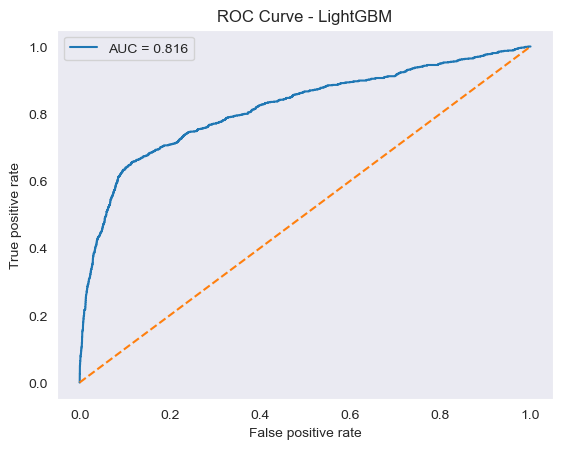

In [107]:
# ROC curve for the best model
y_proba = lgbm_final.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label = f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle = '--')

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC Curve - LightGBM')

plt.legend()
plt.grid()
plt.savefig('ROC.png', dpi=300, bbox_inches='tight')
plt.show()

Conclusion: The ROC curve shows that the model can distinguish between classes quite well.
The AUC score is around 0.81, which indicates good performance.

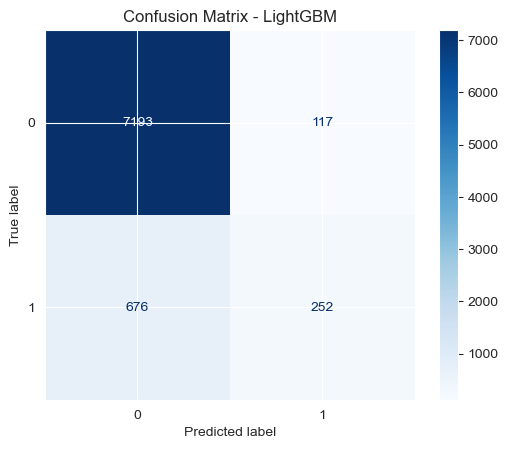

In [113]:
# Confusion matrix
cm = confusion_matrix(y_test, lgbm_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - LightGBM')
plt.savefig('ConfusionMatrix.png', dpi=300, bbox_inches='tight')
plt.show()

Conclusion: The confusion matrix shows that the model correctly predicts most negative cases.

However, it makes mistakes in predicting positive cases, especially false negatives.

This explains the lower F1-score and suggests that the model has difficulty identifying all positive clients.

In [84]:
# Comparison table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (tuned)',
        'kNN (k=80)',
        'Decision Tree (depth=7)',
        'LightGBM (RandomSearch)',
        'LightGBM (Hyperopt)'
    ],

    'Hyperparameters': [
        'C=1.0, class_weight=balanced, threshold=0.6',
        'n_neighbors=80',
        'max_depth=7',
        'RandomizedSearchCV tuned',
        'Hyperopt tuned'
    ],

    'Train ROC-AUC': [
        0.795,
        0.92,
        0.80,
        0.85,
        0.846
    ],

    'Test ROC-AUC': [
        0.800,
        0.78,
        0.796,
        0.814,
        0.816
    ],

    'Train F1': [
        0.27,
        0.48,
        0.44,
        0.43,
        0.434
    ],

    'Test F1': [
        0.27,
        0.32,
        0.41,
        0.38,
        0.388
    ],

    'Comment': [
        'Good baseline, stable',
        'Overfitting reduced, but weaker than Log.Reg.',
        'Good balance, interpretable',
        'Strong performance',
        'Best overall model'
    ]
})

results

,Model,Hyperparameters,Train ROC-AUC,Test ROC-AUC,Train F1,Test F1,Comment
0,Logistic Regression (tuned),"C=1.0, class_weight=balanced, threshold=0.6",0.80,0.80,0.27,0.27,"Good baseline, stable"
1,kNN (k=80),n_neighbors=80,0.92,0.78,0.48,0.32,"Overfitting reduced, but weaker than Log.Reg."
2,Decision Tree (depth=7),max_depth=7,0.80,0.80,0.44,0.41,"Good balance, interpretable"
3,LightGBM (RandomSearch),RandomizedSearchCV tuned,0.85,0.81,0.43,0.38,Strong performance
4,LightGBM (Hyperopt),Hyperopt tuned,0.85,0.82,0.43,0.39,Best overall model


In [120]:
# results for GitHub
with open('table.md', 'w') as f:
    f.write(results.round(3).to_markdown(index=False))

In [82]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_final.feature_importances_
}).sort_values(by='importance', ascending=False)
feature_importance.head(10)

,feature,importance
7,euribor3m,3419
0,age,3287
1,campaign,1520
5,cons.price.idx,875
6,cons.conf.idx,625
3,previous,501
2,pdays,433
47,day_of_week_mon,357
37,contact_telephone,334
4,emp.var.rate,277


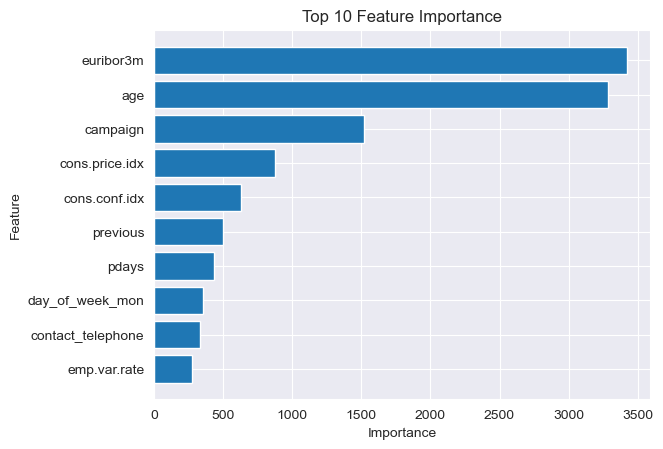

In [110]:
# feature importance visualization
plt.figure()
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.savefig('Feature Importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Conclusion:** Feature importance analysis shows that the most influential features are:

* *euribor3m* (interest rate)
* age
* *campaign* (number of contacts)
* macroeconomic indicators (*cons.price.idx, cons.conf.idx*)

These features are logically justified from a business point of view:

* *euribor3m* reflects overall economic conditions and affects customers’ financial decisions
* age is related to customer behavior and financial stability
* *campaign* reflects marketing intensity (too many contacts may reduce effectiveness)
* macroeconomic indicators describe the general economic environment

Overall, the model takes into account both individual customer characteristics and external economic factors, which makes sense.


In [91]:
# shap
explainer = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_train)

/Users/macbook/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


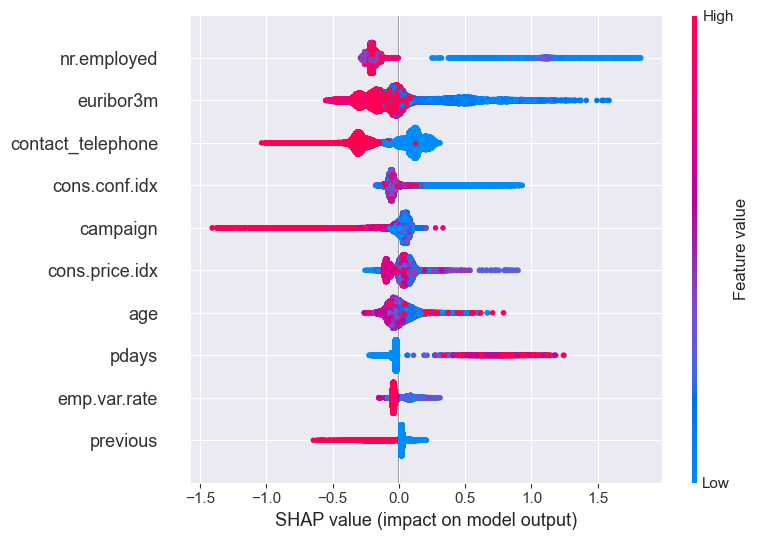

In [109]:
# explainer visualization
shap.summary_plot(shap_values, X_train, feature_names = original_columns, max_display = 10, show = False)
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

**Conclusion:** SHAP analysis shows that the most important features are:

- macroeconomic indicators: *nr.employed*, *euribor3m*
- campaign-related features: *campaign*, *pdays*

Age is not very important on its own, but it works together with other features. The same is true for *cons.price.idx*.

The feature *poutcome_success* has a positive effect — if a client agreed before, they are more likely to agree again.


In [102]:
# errors analysis
# predictions
y_pred = lgbm_final.predict(X_test)

# create analysis df
analysis_df = X_test.copy()

analysis_df['y_true'] = y_test.values
analysis_df['y_pred'] = y_pred

# FP
fp = analysis_df.query('y_true == 0 and y_pred == 1')
fp.head()





,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_missing,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_missing,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_missing,education_professional.course,education_university.degree,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_true,y_pred
40076,73,2,-1,0,-1.70,94.22,-40.30,0.81,4991.60,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,0,1
30307,37,1,2,1,-1.80,93.08,-47.10,1.36,5099.10,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,0,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,0,1
40040,30,2,3,1,-1.70,94.22,-40.30,0.80,4991.60,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,0,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,0,1
39572,30,1,6,1,-1.80,93.88,-40.00,0.67,5008.70,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,0,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,0,1
39743,49,1,-1,1,-1.80,93.88,-40.00,0.70,5008.70,0,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,0,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,0,1


In [103]:
# FN
fn = analysis_df.query('y_true == 1 and y_pred == 0')
fn.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_missing,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_missing,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_missing,education_professional.course,education_university.degree,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_true,y_pred
38884,68,2,-1,1,-3.40,92.65,-30.10,0.71,5017.50,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,0,True,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,1,0
28008,30,2,-1,0,-1.80,93.08,-47.10,1.48,5099.10,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,1,0
16326,38,8,-1,0,1.40,93.92,-42.70,4.96,5228.10,0,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,True,0,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,1,0
26933,34,2,-1,1,-0.10,93.20,-42.00,4.08,5195.80,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,0,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,1,0
37582,29,3,-1,0,-2.90,92.20,-31.40,0.87,5076.20,0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,0,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1,0


**Conclusion:** Error analysis shows that the model often makes mistakes for clients who were not contacted before (*pdays = -1*) and for those with little information (*previous ≈ 0*).

It is also clear that the model does not always handle the number of contacts (*campaign*) correctly: sometimes it overestimates clients with few contacts and underestimates those with more contacts.

This suggests that the model does not fully capture the relationship between contact history and customer behavior.

To improve the model, we can try creating new features or better processing the existing ones. Additionaly, techniques such as SMOTE can be explored to address class imbalance.


## Conclusion

In this project, I built and compared several machine learning models to predict customer conversion.

LightGBM showed the best performance among all models. Hyperparameter tuning slightly improved the results, but overall performance was limited by the data.

Class imbalance was handled using class weights and threshold tuning. SMOTE was considered as an alternative approach but was not included in the final version.

SHAP analysis helped to understand how different features affect the predictions. The most important factors were economic indicators and campaign-related features.

Error analysis showed that the model has difficulties with new clients and cases where the effect of campaign is not clear.

Overall, this project demonstrates the full machine learning workflow: data analysis, model training, tuning, interpretation, and evaluation.